In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb

In [ ]:
train_df = pd.read_csv('/content/training.csv')
test_df = pd.read_csv('/content/test.csv')

In [ ]:
display(train_df.head())
display(test_df.head())

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,350000,-999.000,79.589,23.916,3.036,-999.000,-999.000,-999.000,0.903,3.036,...,2.022,98.556,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000
1,350001,106.398,67.490,87.949,49.994,-999.000,-999.000,-999.000,2.048,2.679,...,-1.138,176.251,1,47.575,-0.553,-0.849,-999.000,-999.000,-999.000,47.575
2,350002,117.794,56.226,96.358,4.137,-999.000,-999.000,-999.000,2.755,4.137,...,-1.868,111.505,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
3,350003,135.861,30.604,97.288,9.104,-999.000,-999.000,-999.000,2.811,9.104,...,1.172,164.707,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
4,350004,74.159,82.772,58.731,89.646,1.347,536.663,-0.339,1.028,77.213,...,-0.231,869.614,3,254.085,-1.013,-0.334,185.857,0.335,2.587,599.213


In [ ]:
test_df_imputed = test_df.copy()
test_df_imputed.replace(-999.0, pd.NA, inplace=True)
test_cols_to_impute = test_df_imputed.columns.drop('EventId')


print("Data types before conversion:")
print(test_df_imputed.dtypes)


print("\nUnique values in 'PRI_jet_subleading_phi' before conversion:")
print(test_df_imputed['PRI_jet_subleading_phi'].unique())

# Convert columns to numeric, coercing errors to NaN
for col in test_cols_to_impute:
    test_df_imputed[col] = pd.to_numeric(test_df_imputed[col], errors='coerce')

# Impute missing values with the median of each column
test_df_imputed[test_cols_to_impute] = test_df_imputed[test_cols_to_impute].fillna(test_df_imputed[test_cols_to_impute].median())

# Verify no remaining missing values in the imputed columns
print("\nMissing values in test_df_imputed (imputed columns) after conversion and imputation:")
print(test_df_imputed[test_cols_to_impute].isnull().sum().sum())

Data types before conversion:
EventId                          int64
DER_mass_MMC                    object
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet            object
DER_mass_jet_jet                object
DER_prodeta_jet_jet             object
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality          object
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt              ob

In [ ]:
train_df_imputed = train_df.copy()

train_df_imputed.replace(-999.0, pd.NA, inplace=True)


train_cols_to_impute = train_df_imputed.columns.drop(['EventId', 'Weight', 'Label'])

# Convert columns to numeric, coercing errors to NaN
for col in train_cols_to_impute:
    train_df_imputed[col] = pd.to_numeric(train_df_imputed[col], errors='coerce')

# Impute missing values with the median of each column
train_df_imputed[train_cols_to_impute] = train_df_imputed[train_cols_to_impute].fillna(train_df_imputed[train_cols_to_impute].median())

# Verify no remaining missing values in the imputed columns
print("Missing values in train_df_imputed (imputed columns) after conversion and imputation:")
print(train_df_imputed[train_cols_to_impute].isnull().sum().sum())

Missing values in train_df_imputed (imputed columns) after conversion and imputation:
0


In [ ]:
X = train_df_imputed.drop(['EventId', 'Weight', 'Label'], axis=1)
y = train_df_imputed['Label']

y = y.map({'s': 1, 'b': 0})

# Split data into training, validation, and a temporary test set (70/30 split)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the temporary test set into validation and final test sets (15/15 split from original)
X_val, X_test_raw, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Display shapes of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of X_test_raw:", X_test_raw.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (175000, 30)
Shape of X_val: (37500, 30)
Shape of X_test_raw: (37500, 30)
Shape of y_train: (175000,)
Shape of y_val: (37500,)
Shape of y_test: (37500,)


In [ ]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_raw)


test_df_features = test_df_imputed.drop('EventId', axis=1)
test_df_scaled_features = scaler.transform(test_df_features)

# Convert scaled NumPy arrays back to pandas DataFrames
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_raw.columns, index=X_test_raw.index)

# Convert scaled test data NumPy array back to pandas DataFrame and add 'EventId' back
test_df_scaled = pd.DataFrame(test_df_scaled_features, columns=test_df_features.columns)
test_df_scaled['EventId'] = test_df_imputed['EventId'].values

display(X_train_scaled_df.head())
display(test_df_scaled.head())

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
192448,0.220678,0.135733,0.365284,-0.878225,-0.092947,-0.190218,0.087467,0.785258,-0.779700,-0.557430,...,-1.548874,-0.310291,-1.000644,-0.240510,0.000845,-0.010423,-0.159784,0.001111,0.000969,-0.745371
139604,-0.397723,-1.052449,-0.464421,-0.316586,3.652582,1.798862,-3.889727,0.307743,-0.869307,-0.179908,...,0.698558,-0.344383,1.042678,-0.772880,1.998932,-1.722983,-0.675649,-2.639599,-0.292768,0.058478
140914,-0.143085,-0.603870,-0.439747,0.621700,-0.584009,-0.231637,0.546747,-0.555360,2.337362,1.220883,...,1.042023,1.266273,2.064340,1.022950,-0.239069,-1.086829,0.070901,-1.789170,2.161158,1.535534
80088,-0.143066,-0.955403,-0.029896,-0.591688,-0.092947,-0.190218,0.087467,0.752062,0.553978,-0.269759,...,-0.745431,-0.427421,0.021017,-0.555624,0.302907,1.541139,-0.159784,0.001111,0.000969,-0.230466
72918,0.037329,-0.956733,0.161919,-0.386409,-0.092947,-0.190218,0.087467,0.503090,0.231615,-0.335906,...,-1.607407,-0.396935,0.021017,-0.906103,0.859336,-0.897336,-0.159784,0.001111,0.000969,-0.402016


,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,EventId
0,-0.149486,0.859799,-1.407617,-0.864018,-0.101359,-0.188696,0.087467,-1.878104,-0.737886,-0.884461,...,-0.879913,-1.000644,-0.235036,0.000845,-0.021109,-0.154217,-0.001626,-0.021470,-0.745371,350000
1,-0.266803,0.517379,0.166048,-0.124396,-0.101359,-0.188696,0.087467,-0.416191,-0.754436,-0.220857,...,-0.265645,0.021017,-0.615552,-0.398772,-0.591725,-0.154217,-0.001626,-0.021470,-0.259800,350001
2,-0.049696,0.198591,0.372706,-0.846676,-0.101359,-0.188696,0.087467,0.486492,-0.686848,-0.525384,...,-0.777536,-1.000644,-0.235036,0.000845,-0.021109,-0.154217,-0.001626,-0.021470,-0.745371,350002
3,0.294501,-0.526550,0.395561,-0.768442,-0.101359,-0.188696,0.087467,0.557991,-0.456595,-0.555504,...,-0.356914,-1.000644,-0.235036,0.000845,-0.021109,-0.154217,-0.001626,-0.021470,-0.745371,350003
4,-0.880993,0.949883,-0.552009,0.500152,-0.892105,1.197152,0.038933,-1.718507,2.700705,4.862689,...,5.216182,2.064340,3.690577,-0.731184,-0.224850,7.598434,0.315916,2.641541,5.370462,350004


In [ ]:
model = Sequential()


model.add(Dense(units=128, activation='relu', input_shape=(X_train_scaled_df.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Dense(units=64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(units=1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile the model
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)
callbacks_list = [early_stopping, reduce_lr]

In [ ]:
history = model.fit(
    X_train_scaled_df,
    y_train,
    validation_data=(X_val_scaled_df, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_list
)

Epoch 1/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.7570 - loss: 0.5014 - val_accuracy: 0.8320 - val_loss: 0.3731 - learning_rate: 0.0010
Epoch 2/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8192 - loss: 0.4036 - val_accuracy: 0.8358 - val_loss: 0.3655 - learning_rate: 0.0010
Epoch 3/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8236 - loss: 0.3953 - val_accuracy: 0.8365 - val_loss: 0.3635 - learning_rate: 0.0010
Epoch 4/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8274 - loss: 0.3878 - val_accuracy: 0.8377 - val_loss: 0.3620 - learning_rate: 0.0010
Epoch 5/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8281 - loss: 0.3840 - val_accuracy: 0.8372 - val_loss: 0.3636 - learning_rate: 0.0010
Epoch 6/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8280 - loss: 0.3863 - val_accuracy: 0.8395 - val_loss: 0.3610 - learning_rate: 0.0010
Epoch 7/100
2735/2735 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0

In [ ]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled_df, y_test, verbose=0)
print(f"Neural Network Test Accuracy: {accuracy:.4f}")

# Predict probabilities on the test set
y_pred_proba_nn = model.predict(X_test_scaled_df).ravel()

# Convert probabilities to binary predictions (0 or 1)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Calculate other metrics
precision_nn = precision_score(y_test, y_pred_nn)
recall_nn = recall_score(y_test, y_pred_nn)
f1_nn = f1_score(y_test, y_pred_nn)
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)

print(f"Neural Network Test Precision: {precision_nn:.4f}")
print(f"Neural Network Test Recall: {recall_nn:.4f}")
print(f"Neural Network Test F1 Score: {f1_nn:.4f}")

Neural Network Test Accuracy: 0.8421
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Neural Network Test Precision: 0.7923
Neural Network Test Recall: 0.7188
Neural Network Test F1 Score: 0.7537


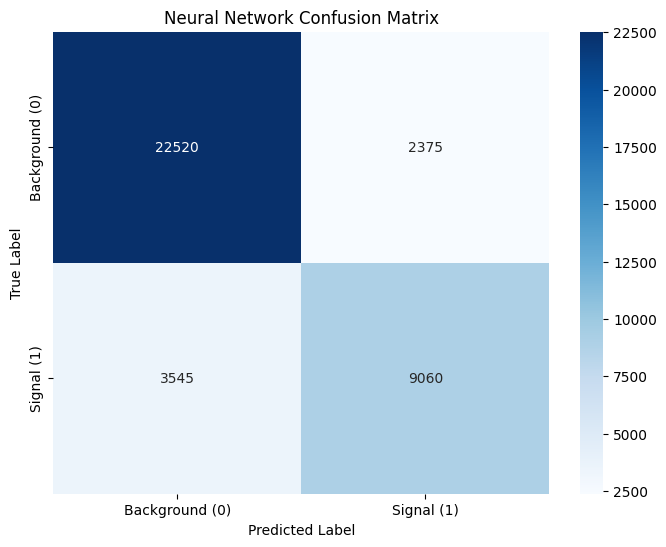

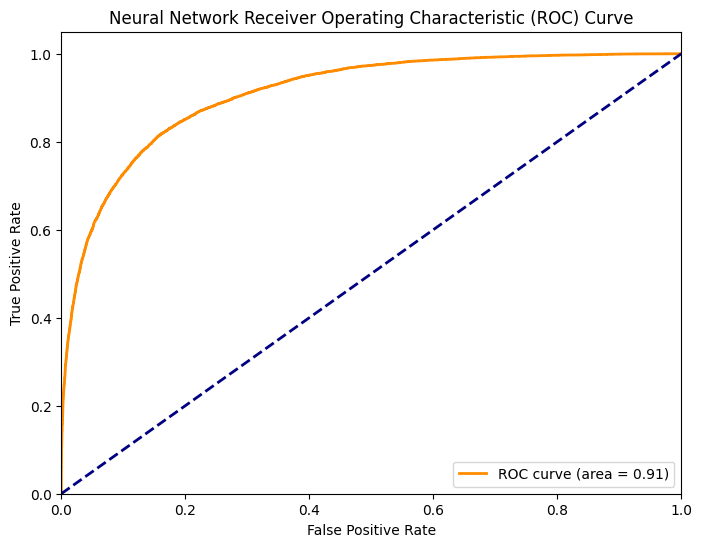

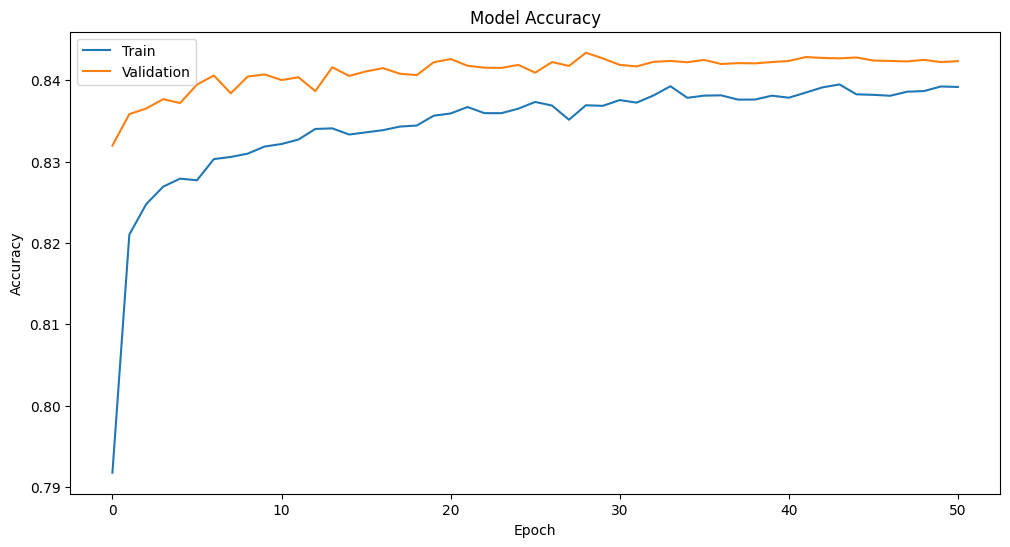

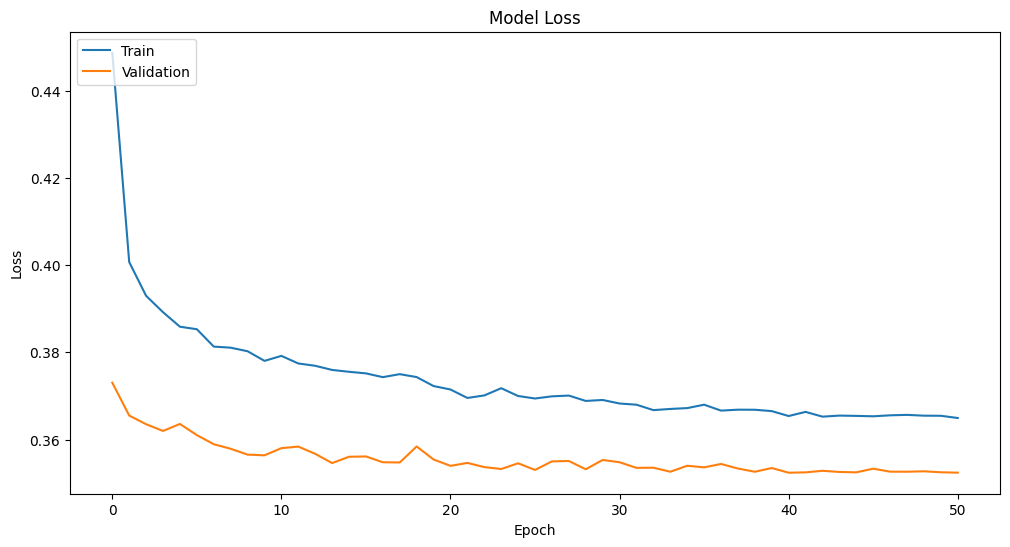

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='Blues', xticklabels=['Background (0)', 'Signal (1)'], yticklabels=['Background (0)', 'Signal (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Neural Network Confusion Matrix')
plt.show()

# Plot ROC Curve
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_nn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Neural Network Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)
xgb_model.fit(X_train_scaled_df, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled_df)[:, 1]
y_pred_xgb = (y_pred_proba_xgb > 0.5).astype(int)

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Test Accuracy: {accuracy_xgb:.4f}")
print(f"XGBoost Test Precision: {precision_xgb:.4f}")
print(f"XGBoost Test Recall: {recall_xgb:.4f}")
print(f"XGBoost Test F1 Score: {f1_xgb:.4f}")

XGBoost Test Accuracy: 0.8370
XGBoost Test Precision: 0.7733
XGBoost Test Recall: 0.7288
XGBoost Test F1 Score: 0.7504


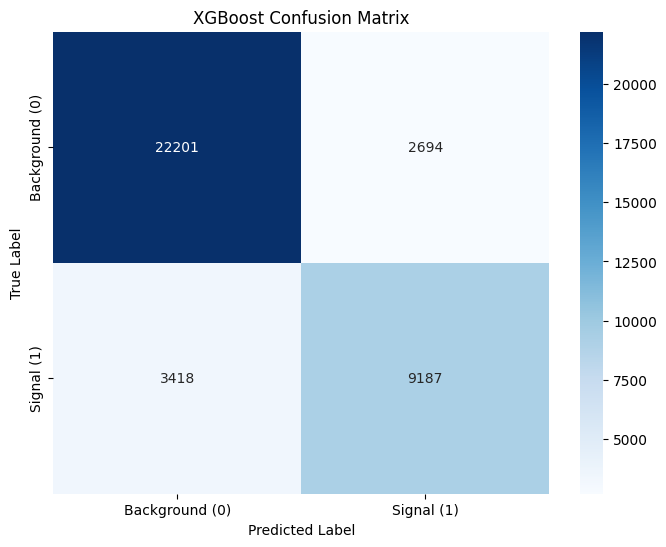

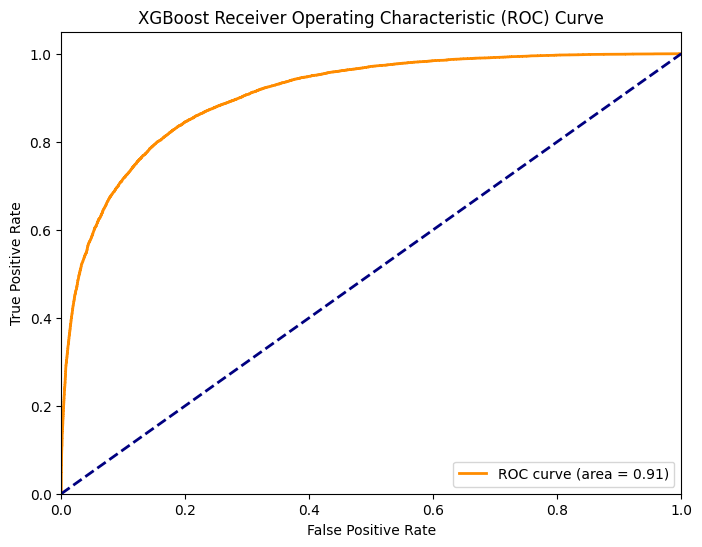

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Background (0)', 'Signal (1)'], yticklabels=['Background (0)', 'Signal (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('XGBoost Confusion Matrix')
plt.show()

# Plot ROC Curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
print("Model Performance Comparison:")
print("-" * 30)
print(f"Metric          | Neural Network | XGBoost")
print("-" * 30)
print(f"Accuracy        | {accuracy:.4f}         | {accuracy_xgb:.4f}")
print(f"Precision       | {precision_nn:.4f}         | {precision_xgb:.4f}")
print(f"Recall          | {recall_nn:.4f}         | {recall_xgb:.4f}")
print(f"F1 Score        | {f1_nn:.4f}         | {f1_xgb:.4f}")
print(f"ROC AUC Score   | {roc_auc_nn:.4f}         | {roc_auc_xgb:.4f}")
print("-" * 30)

Model Performance Comparison:
------------------------------
Metric          | Neural Network | XGBoost
------------------------------
Accuracy        | 0.8421         | 0.8370
Precision       | 0.7923         | 0.7733
Recall          | 0.7188         | 0.7288
F1 Score        | 0.7537         | 0.7504
ROC AUC Score   | 0.9097         | 0.9062
------------------------------


**Reflection:**

*   **How did model depth and activation affect performance?**
    *   The current neural network has three hidden layers with ReLU activation. Increasing the depth might allow the model to capture more complex interactions between features, potentially improving performance. However, it could also lead to overfitting if not properly regularized. Different activation functions like Leaky ReLU or ELU could also be explored for potential performance gains.

*   **What helped mitigate overfitting?**
    *   Several techniques were used to mitigate overfitting:
        *   **Dropout:** This technique randomly sets a fraction of input units to 0 at each update during training, which helps prevent the network from becoming too reliant on specific neurons.
        *   **Batch Normalization:** This layer normalizes the inputs to the activation function, which helps stabilize the learning process and allows for higher learning rates. It also has a regularization effect.
        *   **Early Stopping:** This callback monitors the validation loss and stops training when it stops improving, preventing the model from overfitting to the training data.
        *   **ReduceLROnPlateau:** This callback reduces the learning rate when the validation loss plateaus, allowing the model to converge more effectively.

*   **How did the learning rate and optimizer affect convergence?**
    *   The Adam optimizer with an initial learning rate of 0.001 was used. Adam is generally a good choice for many tasks and adapts the learning rate for each parameter. The `ReduceLROnPlateau` callback dynamically adjusted the learning rate during training, which likely helped the model converge more effectively by allowing for larger steps initially and smaller adjustments as the model approached the minimum of the loss function. Experimenting with different optimizers (like RMSprop) and learning rate schedules could further impact convergence speed and final performance.

*   **What would you improve with more time or compute?**
    *   **Hyperparameter Tuning:** Systematically tune the hyperparameters of both the neural network (number of layers, units per layer, dropout rates, learning rate, batch size) and the XGBoost model (e.g., `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`) using techniques like Grid Search or Random Search.
    *   **Cross-validation:** Implement k-fold cross-validation for more robust evaluation of model performance and to reduce the variance of the performance estimates.
    *   **Feature Engineering:** Explore creating new features from the existing ones to potentially provide more informative inputs to the models.
    *   **Ensemble Methods:** Combine the predictions of the neural network and XGBoost models (or other models) to potentially achieve better performance than any single model.
    *   **More Complex Models:** Experiment with more advanced neural network architectures or other machine learning algorithms.